In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

## Step 1: Reading the Data and A/B Test Results

### Reading the Data

In [11]:
ab_test = pd.read_csv("ab_test_data - ab_test_data.csv")

### Converting Date Column into Datetime Format

In [10]:
ab_test["timestamp"] = pd.to_datetime(ab_test["timestamp"])

### Summary Table by Group

In [5]:
ab_summary = ab_test.groupby("test_group").agg(
    user_count=("user_id", "nunique"),
    conversion_count=("conversion", "sum")
)

### Conversion Rate

In [6]:
ab_summary["conversion_rate"] = ab_summary["conversion_count"] / ab_summary["user_count"]

### For Percentage Format

In [7]:
ab_summary["conversion_rate_percent"] = ab_summary["conversion_rate"] * 100

In [8]:
ab_summary

,user_count,conversion_count,conversion_rate,conversion_rate_percent
test_group,,,,
a,10013,611,0.061021,6.102067
b,9985,889,0.089034,8.903355


## Test Dates and Durations

### Convert the Column to Datetime

In [14]:
ab_test["timestamp"] = pd.to_datetime(ab_test["timestamp"])

### The Start and The End Dates For A/B Testing

In [16]:
start_date = ab_test["timestamp"].min()
end_date = ab_test["timestamp"].max()

### Test Duration

In [17]:
test_duration = (end_date.normalize() - start_date.normalize()).days + 1

In [18]:
start_date

Timestamp('2023-07-03 01:42:34')

In [20]:
end_date

Timestamp('2023-07-25 01:41:19')

In [21]:
test_duration

23

### Brief Comment

Group B’s conversion rate was calculated as 8.90%, while Group A’s conversion rate was 6.10%. At first glance, Group B appears to perform better. However, before making a final decision, a hypothesis test should be conducted in the next step. Declaring victory based only on raw conversion rates would be the Stone Age version of data analysis.

## Step 2: Hypothesis Testing

To compare the conversion rates of Group A and Group B, I used a two-proportion z-test.

This test is appropriate because the metric is binary: each user either converted or did not convert. Therefore, we are comparing two independent conversion proportions.

**Null Hypothesis H₀:**  
There is no statistically significant difference between the conversion rates of Group A and Group B.

**Alternative Hypothesis H₁:**  
There is a statistically significant difference between the conversion rates of Group A and Group B.

The two-proportion z-test produced the following results:

- Z-statistic: -7.52
- P-value: 5.49e-14
- Significance level: 0.05

Since the p-value is much smaller than 0.05, the null hypothesis is rejected.

Group A had a conversion rate of 6.10%, while Group B had a conversion rate of 8.90%. The absolute lift was 2.80 percentage points, and the relative lift was approximately 45.91%.

This means that Group B performed statistically significantly better than Group A. Therefore, the 50% discount offer had a statistically significant positive effect on conversion rate.

### Conversion Numbers for A and B Groups

In [30]:
conversion_counts = [
    ab_summary.loc["a", "conversion_count"],
    ab_summary.loc["b", "conversion_count"]
]

In [32]:
conversion_counts

[np.int64(611), np.int64(889)]

### User Count for A and B Groups

In [41]:
user_counts = [
    ab_summary.loc["a", "user_count"],
    ab_summary.loc["b", "user_count"]
]

In [42]:
user_counts

[np.int64(10013), np.int64(9985)]

### Two-proportion Z-test

In [40]:
z_stat, p_value = proportions_ztest(
    count=conversion_counts,
    nobs=user_counts
)

In [36]:
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -7.519675939906207
P-value: 5.491217728445103e-14


### Conversion Rate Differences

In [37]:
p_A = ab_summary.loc["a", "conversion_rate"]
p_B = ab_summary.loc["b", "conversion_rate"]

In [38]:
absolute_lift = p_B - p_A
relative_lift = absolute_lift / p_A

In [43]:
print(f"Z-statistic: {z_stat:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Group A conversion rate: {p_A:.2%}")
print(f"Group B conversion rate: {p_B:.2%}")
print(f"Absolute lift: {absolute_lift:.2%}")
print(f"Relative lift: {relative_lift:.2%}")

Z-statistic: -7.52
P-value: 5.49e-14
Group A conversion rate: 6.10%
Group B conversion rate: 8.90%
Absolute lift: 2.80%
Relative lift: 45.91%


## Step 3: Visualization with 95% Confidence Intervals

I visualized the conversion rates of Group A and Group B using a bar chart with 95% confidence intervals.

The confidence intervals were calculated using the standard error of a proportion:

- p̂ = x / n
- SE = sqrt(p̂(1 - p̂) / n)
- 95% CI = p̂ ± 1.96 × SE

Group A had a conversion rate of 6.10%, while Group B had a conversion rate of 8.90%.

The visualization shows that Group B achieved a higher conversion rate than Group A. This supports the hypothesis test result and suggests that the 50% discount offer had a positive effect on conversion.

### Calculate Conversion Rate

In [45]:
ab_summary["conversion_rate"] = (
    ab_summary["conversion_count"] / ab_summary["user_count"]
)

### Standard Error

In [46]:
ab_summary["se"] = np.sqrt(
    ab_summary["conversion_rate"] 
    * (1 - ab_summary["conversion_rate"]) 
    / ab_summary["user_count"]
)

### 95% Confidence Intervals

In [47]:
ab_summary["ci_lower"] = ab_summary["conversion_rate"] - 1.96 * ab_summary["se"]
ab_summary["ci_upper"] = ab_summary["conversion_rate"] + 1.96 * ab_summary["se"]

### Error Bar Distances

In [48]:
ab_summary["ci_error"] = 1.96 * ab_summary["se"]

In [49]:
ab_summary

,user_count,conversion_count,conversion_rate,conversion_rate_percent,se,ci_lower,ci_upper,ci_error
test_group,,,,,,,,
a,10013,611,0.061021,6.102067,0.002392,0.056332,0.065709,0.004689
b,9985,889,0.089034,8.903355,0.002850,0.083447,0.094620,0.005586


### The Graph

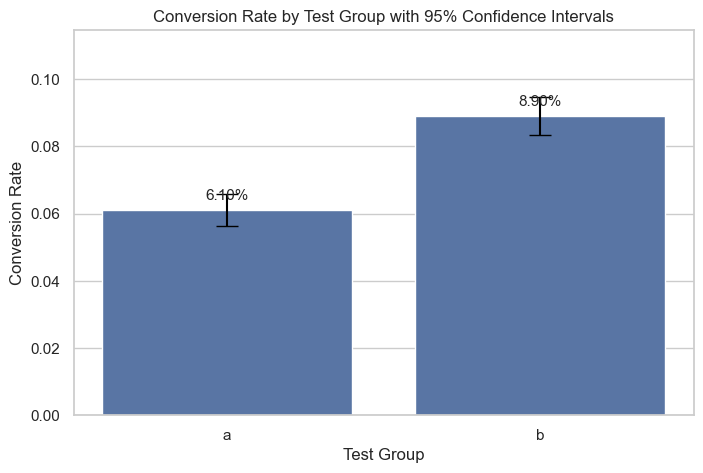

In [53]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=ab_summary.reset_index(),
    x="test_group",
    y="conversion_rate"
)

plt.errorbar(
    x=range(len(ab_summary)),
    y=ab_summary["conversion_rate"],
    yerr=ab_summary["ci_error"],
    fmt="none",
    capsize=8,
    color="black"
)

for i, rate in enumerate(ab_summary["conversion_rate"]):
    plt.text(
        i,
        rate + 0.003,
        f"{rate:.2%}",
        ha="center",
        fontsize=11
    )

plt.title("Conversion Rate by Test Group with 95% Confidence Intervals")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate")
plt.ylim(0, ab_summary["ci_upper"].max() + 0.02)

plt.show()

The I-shaped lines on the bars represent the 95% confidence intervals. They show the uncertainty around each group’s estimated conversion rate. Group B has a higher conversion rate than Group A, and the confidence intervals help visualize the reliability of this difference.

## 4. Results and Decision

### Summary of Results

The A/B test compared the conversion rates of Group A and Group B.

- Group A conversion rate: 6.10%
- Group B conversion rate: 8.90%
- Absolute lift: 2.80 percentage points
- Relative lift: 45.91%
- P-value: 5.49e-14
- Test duration: 23 days
- Sample size:
  - Group A: 10,013 users
  - Group B: 9,985 users

A two-proportion z-test was used to compare the conversion rates of the two groups.

Since the p-value is much smaller than 0.05, the null hypothesis is rejected. This means that the difference between Group A and Group B is statistically significant.

### Decision

Variant B achieved a statistically significantly higher conversion rate than Variant A.

Therefore, I recommend rolling out Variant B, which includes the 50% discount offer.

### Risks and Limitations

- The test ran for 23 days, which is enough to include both weekday and weekend behavior.
- The sample sizes are balanced, with around 10,000 users in each group.
- Additional guardrail metrics such as refund rate, cancellation rate, retention, and revenue per paywall view should be monitored before a full rollout.